In [1]:
# this script is for pv cells
# function to find spike and calculate isi

In [2]:
# use py36, not py3
from ipfx.dataset.create import create_ephys_data_set
from ipfx.utilities import drop_failed_sweeps
from ipfx.epochs import get_stim_epoch
from ipfx.stim_features import get_stim_characteristics
from ipfx.feature_extractor import SpikeFeatureExtractor
from ipfx import spike_train_features

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# read in dataframe containing metadata and nwb-related information
pv_metadata_nwbs = pd.read_csv("L23_pv_metadata_nwbs.csv", index_col=0)

In [4]:
# generate a dataframe containing the unique index and nwb file name
pv_nwb_filelist = pv_metadata_nwbs[['index', 'file_name']]#+ '%0D'
# add '%0D' at the end of each nwb files' names
pv_nwb_filelist.loc[:, 'file_name'] = pv_metadata_nwbs[['file_name']] + '%0D' # for later sweep selecting


D:\softwares\Python\Anaconda\Anaconda3\envs\py36\lib\site-packages\pandas\core\indexing.py:494: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: http://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  self.obj[item] = s


In [5]:
# a function demo, store some sweeps containing spikes >= 20

In [6]:
# try to find spike by myself
# input should have two columns, 'index' for unique index for each cell, 'file_name' for nwb file name
def nwb_to_dict_sweeps(nwb_filelist_table):
    index_col = nwb_filelist_table[['index']]
    nwb_filelist = nwb_filelist_table[['file_name']]
    
    n_cells = len(nwb_filelist)
    result = {}
    for i in range(n_cells):
        # print(n_cells)
        if len(result) >= 10:
            break # stop when we collect 10 sweeps
            
        else:
            nwb_filename = nwb_filelist.iloc[i].values
            nwb_filename = ''.join(nwb_filename) # get one nwb file name
            data_set = create_ephys_data_set(nwb_file = nwb_filename) # load the nwb file in the fold same with this script
            drop_failed_sweeps(data_set) # qc
            long_square_table = data_set.filtered_sweep_table(stimuli=data_set.ontology.long_square_names) # get sweep table for Long Square sweeps
            long_square_sweeps = data_set.sweep_set(long_square_table.sweep_number)
            long_square_sweeps.select_epoch("recording")
            long_square_sweeps.align_to_start_of_epoch("experiment")
            
            # for loop for one cell's sweeps
            for idx, sweep in enumerate(long_square_sweeps.sweeps):
                t_start, duration, i_amp, _, _ = get_stim_characteristics(sweep.i, sweep.t)
                if t_start is None:
                    continue
                spfx = SpikeFeatureExtractor(start = t_start, end = (t_start+duration), min_peak = 20,dv_cutoff=15)
                spike_df = spfx.process(sweep.t, sweep.v, sweep.i)
                
                if len(spike_df) >= 20:
                    t_spike = np.array(spike_df['threshold_t'])
                    isi = np.diff(t_spike)
                    pause = spike_train_features.detect_pauses(isi, spike_df['isi_type'][:-1])
                    burst = spike_train_features.detect_bursts(
                        isi, spike_df['isi_type'][:-1],
                        spike_df['fast_trough_v'], spike_df['fast_trough_t'],
                        spike_df['slow_trough_v'], spike_df['slow_trough_t'],
                        spike_df['threshold_v'])
                    # store the unique index for the cell and the index of this sweep of this cell
                    iloc_idx = str(index_col.loc[i,'index']) + '_' + str(idx)
                    
                    # detect spike
                    t_spike_byhand = np.zeros(0)
                    v_spike_byhand = np.zeros(0)
                    tops_x_v = sweep.v
                    tops_x_t = sweep.t
                    x_max_v = max(tops_x_v)
                    for ii in range(1, len(tops_x_v)-1):
                        if tops_x_v[ii] >= x_max_v*0.7:
                            v_slops_forward = tops_x_v[ii]-tops_x_v[ii-1]
                            v_slops_backward = tops_x_v[ii+1]-tops_x_v[ii]
                            if v_slops_forward >= 0 and v_slops_backward < 0:
                                t_spike_byhand = np.append(t_spike_byhand, tops_x_t[ii])
                                v_spike_byhand = np.append(v_spike_byhand, tops_x_v[ii])
                                x_max_v = tops_x_v[ii] # allow the next spike to be lower and lower
                    x_isi = np.diff(t_spike_byhand)
                    
                    result[iloc_idx] = {
                        'i_amp': i_amp,
                        't_start': t_start,
                        't_end': t_start+duration,
                        't_spike': t_spike,
                        'isi': isi,
                        'pause': pause,
                        'burst': burst,
                        'sweep_i': sweep.i,
                        'sweep_t': sweep.t,
                        'sweep_v': sweep.v,
                        'isi_byhand': x_isi,
                        't_spkie_byhand': t_spike_byhand,
                        'v_spkie_byhand': v_spike_byhand
                    }
                    # print(idx)
    return result
                    
            

In [7]:
# call the demo function
pv_demo_sweeps = nwb_to_dict_sweeps(pv_nwb_filelist)

C:\Users\Yagi\AppData\Roaming\Python\Python36\site-packages\hdmf\spec\namespace.py:533: UserWarning: Ignoring cached namespace 'hdmf-common' version 1.1.3 because version 1.5.0 is already loaded.
  % (ns['name'], ns['version'], self.__namespaces.get(ns['name'])['version']))
C:\Users\Yagi\AppData\Roaming\Python\Python36\site-packages\hdmf\spec\namespace.py:533: UserWarning: Ignoring cached namespace 'core' version 2.2.5 because version 2.3.0 is already loaded.
  % (ns['name'], ns['version'], self.__namespaces.get(ns['name'])['version']))
C:\Users\Yagi\AppData\Roaming\Python\Python36\site-packages\hdmf\spec\namespace.py:533: UserWarning: Ignoring cached namespace 'hdmf-common' version 1.1.3 because version 1.5.0 is already loaded.
  % (ns['name'], ns['version'], self.__namespaces.get(ns['name'])['version']))
C:\Users\Yagi\AppData\Roaming\Python\Python36\site-packages\hdmf\spec\namespace.py:533: UserWarning: Ignoring cached namespace 'core' version 2.2.5 because version 2.3.0 is already l

In [8]:
# check the number of sweeps
len(pv_demo_sweeps)

10

In [9]:
pv_demo_sweeps.keys()

dict_keys(['105_9', '105_10', '284_9', '284_10', '284_11', '284_12', '339_11', '339_12', '355_8', '393_9'])

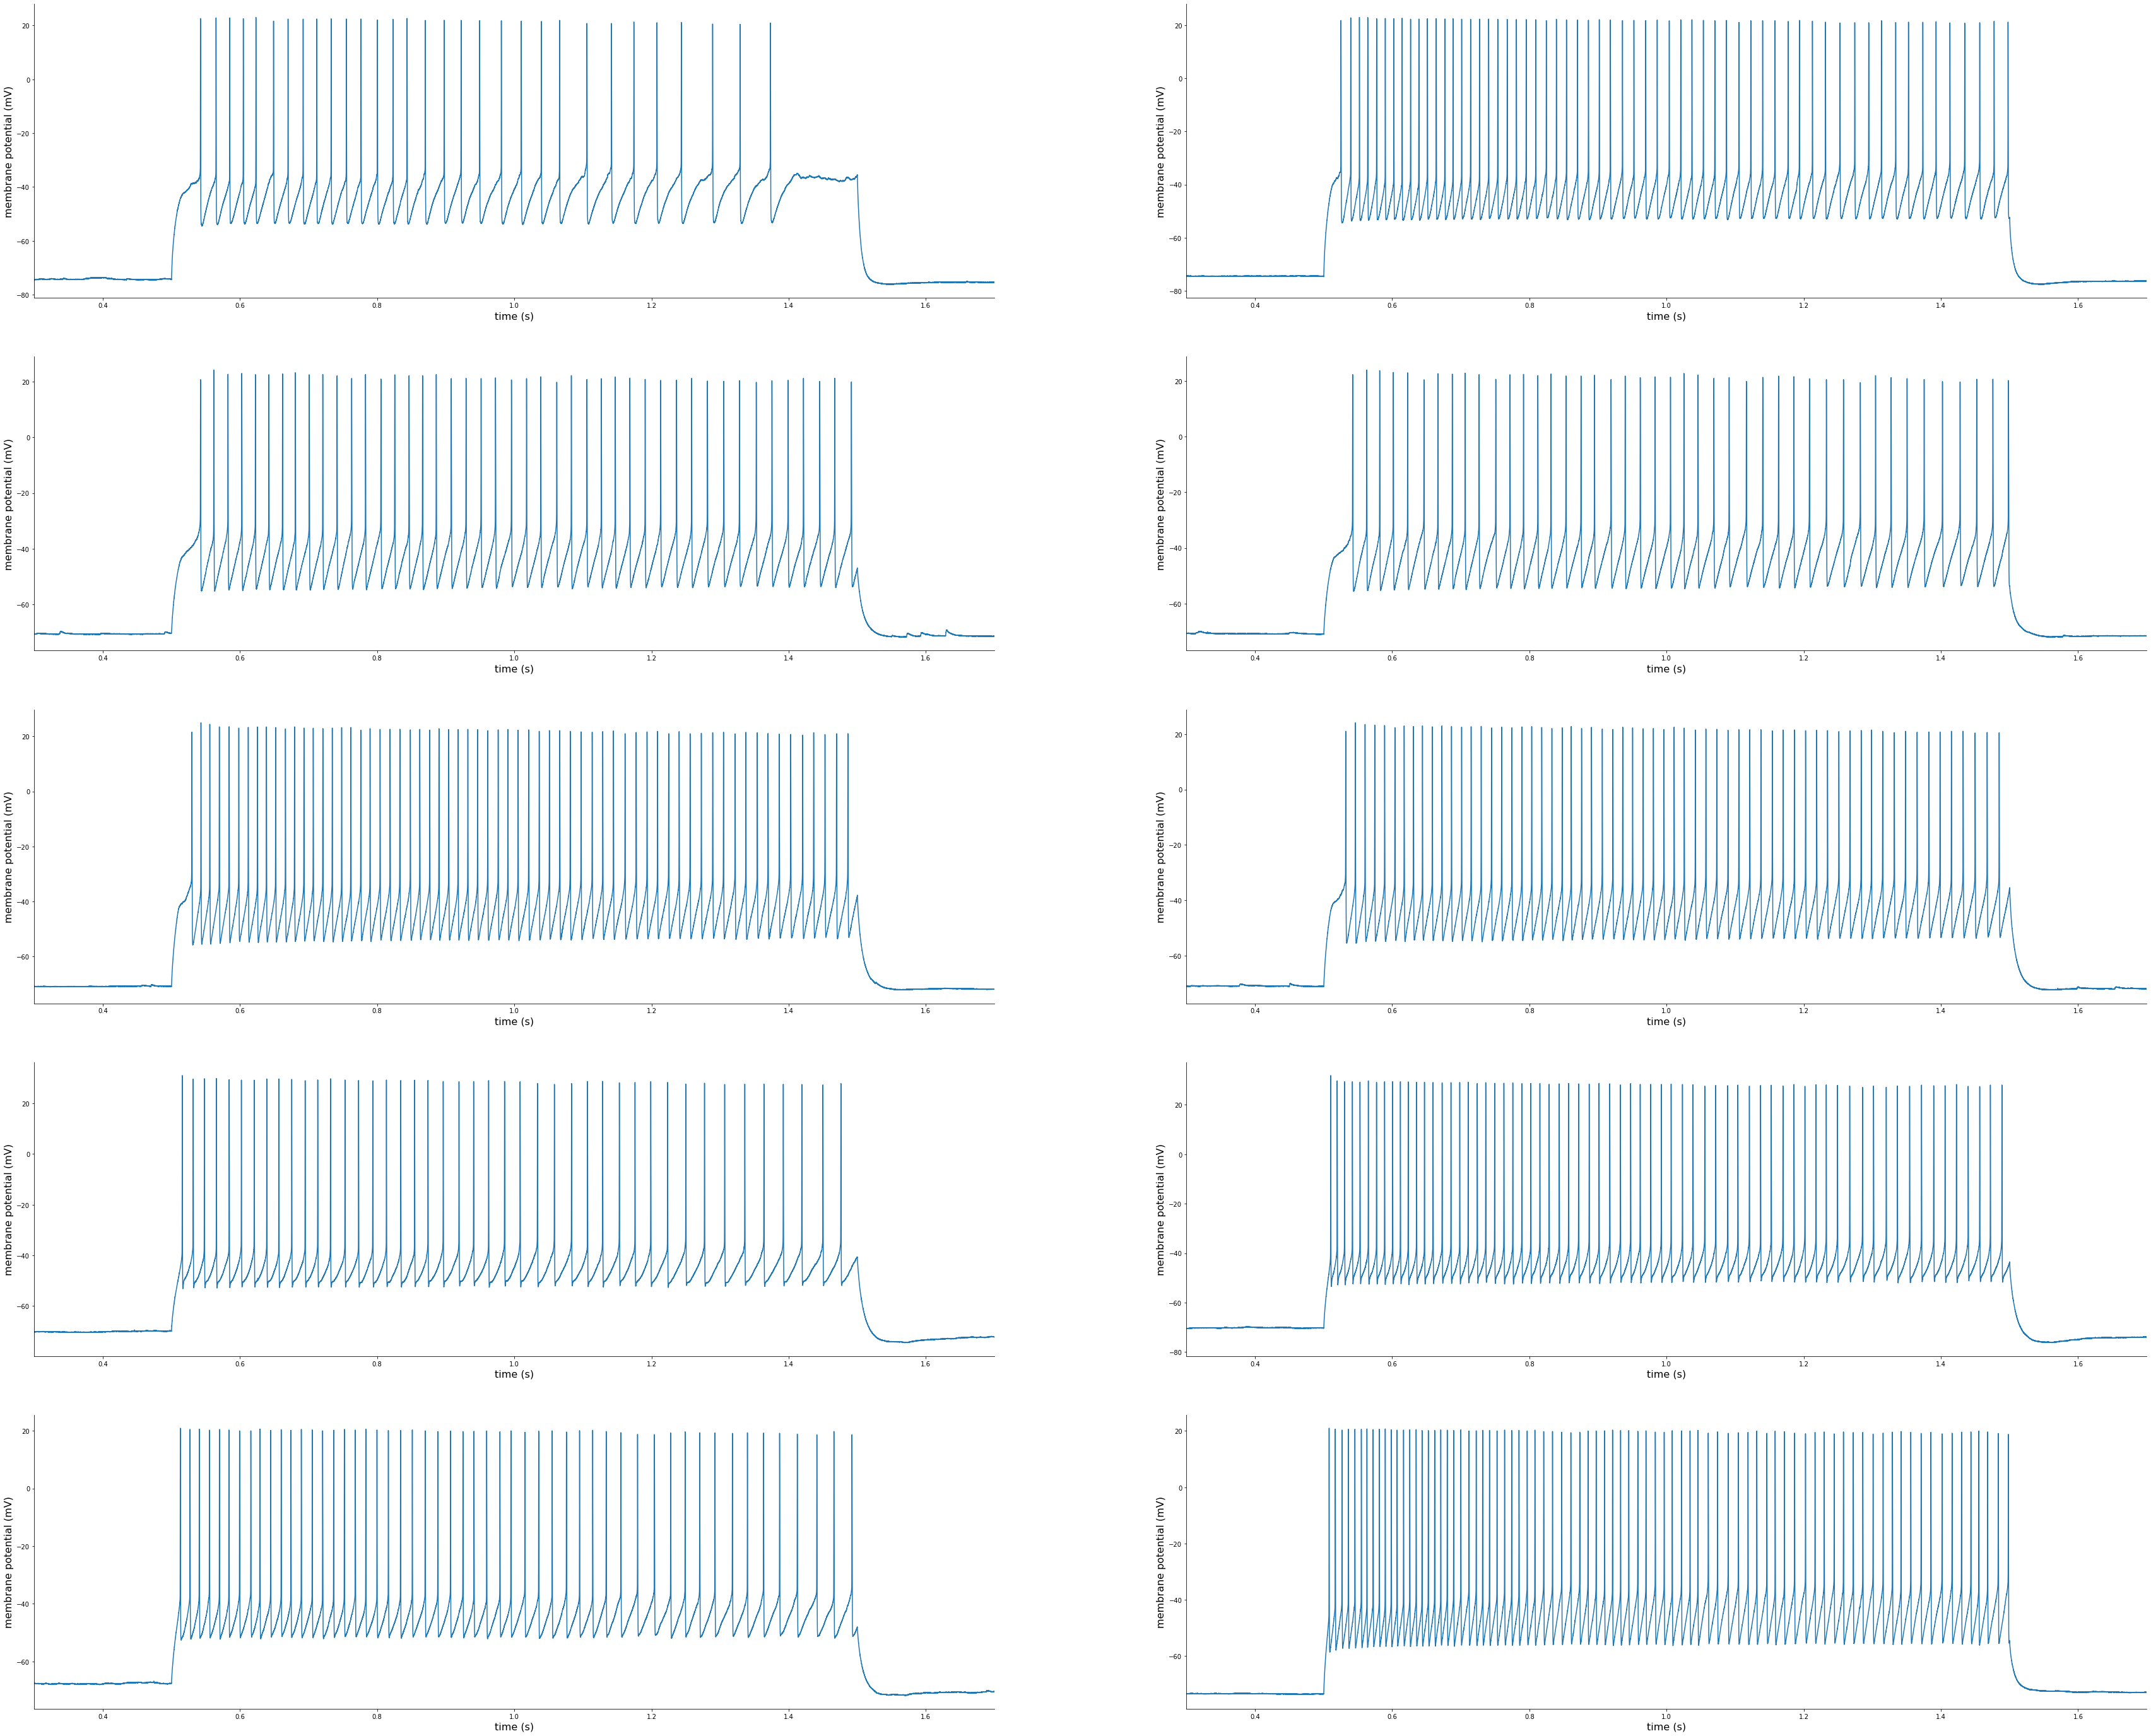

In [10]:
# some plot
pv_demo_key = [cell for cell in pv_demo_sweeps.keys()]

fig, ax = plt.subplots(5,2, figsize=(60,60))
for i in range(10):
    x = pv_demo_sweeps[pv_demo_key[i]]
    plt.subplot(6,2,i+1)
    # plt.subplots(figsize=(15,6))
    plt.plot(x['sweep_t'], x['sweep_v'])
    plt.xlabel("time (s)", fontsize=16)
    plt.ylabel("membrane potential (mV)", fontsize=16)
    axes = plt.gca()
    time_range = [x['t_start']-0.20, x['t_end']+0.20]
    axes.set_xlim(time_range)
    sns.despine()

# plt.savefig('1027_pv_demo.png')
plt.show()

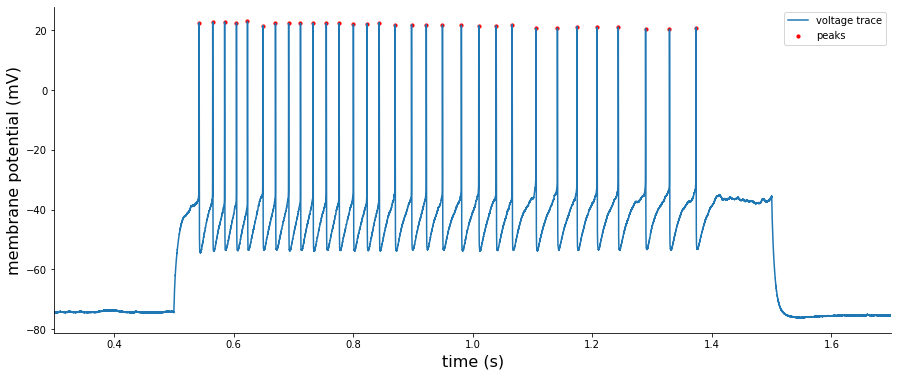

In [11]:
# demo, one sweep to check the spikes found by hand
x = pv_demo_sweeps['105_9']

# plot the voltage trace and spikes found by hand
plt.figure(figsize=(15, 6))

plt.plot(x['sweep_t'], x['sweep_v'], label = 'voltage trace')
plt.scatter(x['t_spkie_byhand'], x['v_spkie_byhand'], s=10, color = 'red', label = "peaks")
#plt.scatter(tops_x_t[0], tops_x_v[0], s=20, color = 'green', label = "first")
plt.xlabel("time (s)", fontsize=16)
plt.ylabel("membrane potential (mV)", fontsize=16)

plt.legend()

axes = plt.gca()
time_range = [x['t_start']-0.20, x['t_end']+0.20]
axes.set_xlim(time_range)
axes = plt.gca()

sns.despine() 

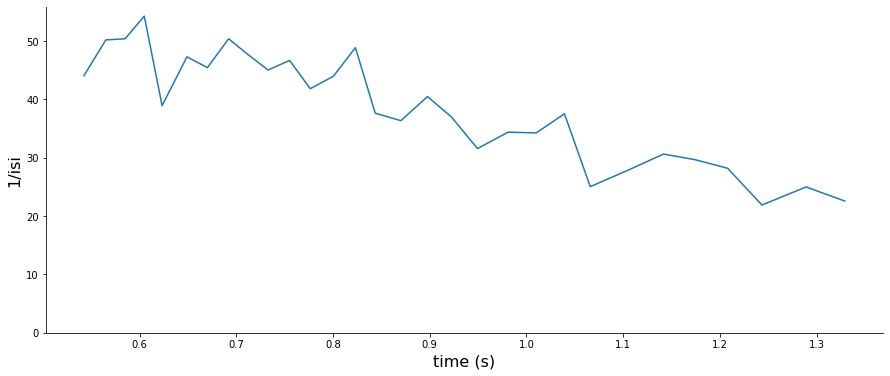

In [12]:
# plot the 1/isi - t found by hand
plt.figure(figsize=(15, 6))

plt.plot(x['t_spkie_byhand'][range(0, len(x['t_spkie_byhand'])-1)], 1/x['isi_byhand'])
plt.xlabel("time (s)", fontsize=16)
plt.ylabel("1/isi", fontsize=16)

axes = plt.gca()
axes.set_ylim([0,None])

sns.despine() 